In [1]:
import numpy as np
import pandas as pd

In [16]:
data = pd.read_csv('logs/session_20250701-143537/session.csv')
data

,request_arrival_time,response_output_time,preprocess_start_time,inference_start_time,inference_end_time,postprocess_start_time,round_trip_time,server_processing_duration,total_network_latency
0,520827.566988,520828.319702,520827.567114,520827.637193,520828.318296,520828.318296,0.797055,0.752714,0.044341
1,520829.687716,520830.234268,520829.687804,520829.689389,520830.232936,520830.232937,0.570527,0.546552,0.023975
2,520831.818944,520832.437642,520831.819016,520831.820749,520832.436001,520832.436002,0.740339,0.618698,0.121641
3,520833.930795,520834.551855,520833.930878,520833.932974,520834.549952,520834.549953,0.642857,0.621060,0.021797
4,520836.071725,520836.710976,520836.071859,520836.074165,520836.709119,520836.709119,0.677311,0.639251,0.038060
5,520838.201849,520838.811346,520838.201924,520838.204202,520838.809533,520838.809534,0.701958,0.609497,0.092461
6,520840.343051,520840.923087,520840.343163,520840.345604,520840.921636,520840.921637,0.603077,0.580036,0.023041
7,520842.470055,520843.090677,520842.470152,520842.472594,520843.088957,520843.088958,0.645039,0.620622,0.024418


In [17]:
# Calculate the duration of each stage by finding the difference between timestamps
data['server_total_duration'] = data['response_output_time'] - data['request_arrival_time']
data['server_preprocess_duration'] = data['inference_start_time'] - data['preprocess_start_time']
data['inference_duration'] = data['inference_end_time'] - data['inference_start_time']
data['server_postprocess_duration'] = data['response_output_time'] - data['postprocess_start_time']
data['request_send_duration'] = data['request_arrival_time'] - data['preprocess_start_time']


# This represents network latency plus any other time not captured by the server's timestamps.
data['network_and_other_latency'] = data['round_trip_time'] - data['server_total_duration']
data['response_receive_duration'] = data['network_and_other_latency'] - data['request_send_duration']

# Create a new DataFrame containing only the calculated durations for clarity
durations_df = data[[
    'round_trip_time',
    'server_total_duration',
    'inference_duration',
    'server_preprocess_duration',
    'server_postprocess_duration',
    'request_send_duration',
    'response_receive_duration',
    'network_and_other_latency'
]]

# Display the calculated durations for each inference request
print("Calculated Durations for Each Request (in seconds):")
display(durations_df)

# Display summary statistics (mean, std, min, max, etc.) for these durations
print("\nSummary Statistics for Durations (in seconds):")
display(durations_df.describe())

Calculated Durations for Each Request (in seconds):


,round_trip_time,server_total_duration,inference_duration,server_preprocess_duration,server_postprocess_duration,request_send_duration,response_receive_duration,network_and_other_latency
0,0.797055,0.752714,0.681103,0.070079,0.001406,-0.000126,0.044467,0.044341
1,0.570527,0.546552,0.543547,0.001585,0.001331,-0.000089,0.024063,0.023975
2,0.740339,0.618698,0.615252,0.001733,0.001640,-0.000072,0.121713,0.121641
3,0.642857,0.621060,0.616978,0.002096,0.001902,-0.000083,0.021880,0.021797
4,0.677311,0.639251,0.634954,0.002306,0.001857,-0.000135,0.038195,0.038060
5,0.701958,0.609497,0.605331,0.002278,0.001812,-0.000075,0.092535,0.092461
6,0.603077,0.580036,0.576032,0.002441,0.001451,-0.000112,0.023152,0.023041
7,0.645039,0.620622,0.616363,0.002442,0.001719,-0.000097,0.024515,0.024418



Summary Statistics for Durations (in seconds):


,round_trip_time,server_total_duration,inference_duration,server_preprocess_duration,server_postprocess_duration,request_send_duration,response_receive_duration,network_and_other_latency
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,0.672270,0.623554,0.611195,0.010620,0.001640,-0.000098,0.048815,0.048717
std,0.073540,0.059747,0.040312,0.024027,0.000220,0.000023,0.037691,0.037703
min,0.570527,0.546552,0.543547,0.001585,0.001331,-0.000135,0.021880,0.021797
25%,0.632912,0.602132,0.598007,0.002006,0.001439,-0.000115,0.023836,0.023741
50%,0.661175,0.619660,0.615807,0.002292,0.001680,-0.000093,0.031355,0.031239
75%,0.711553,0.625608,0.621472,0.002442,0.001824,-0.000081,0.056484,0.056371
max,0.797055,0.752714,0.681103,0.070079,0.001902,-0.000072,0.121713,0.121641


Summary Statistics for Durations (in seconds):


,round_trip_time,server_processing_duration,total_network_latency,inference_duration,server_preprocess_duration,server_postprocess_duration
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000
mean,0.805931,0.155651,0.650280,0.141326,0.013238,0.000978
std,0.103178,0.102557,0.035397,0.080409,0.023995,0.000884
min,0.696648,0.083250,0.606578,0.074854,0.001747,0.000325
25%,0.737368,0.107696,0.617061,0.100018,0.007070,0.000391
50%,0.792936,0.130858,0.647146,0.123091,0.007402,0.000472
75%,0.838407,0.158620,0.672163,0.149281,0.008426,0.001853
max,1.113084,0.496232,0.716864,0.399476,0.096266,0.002408


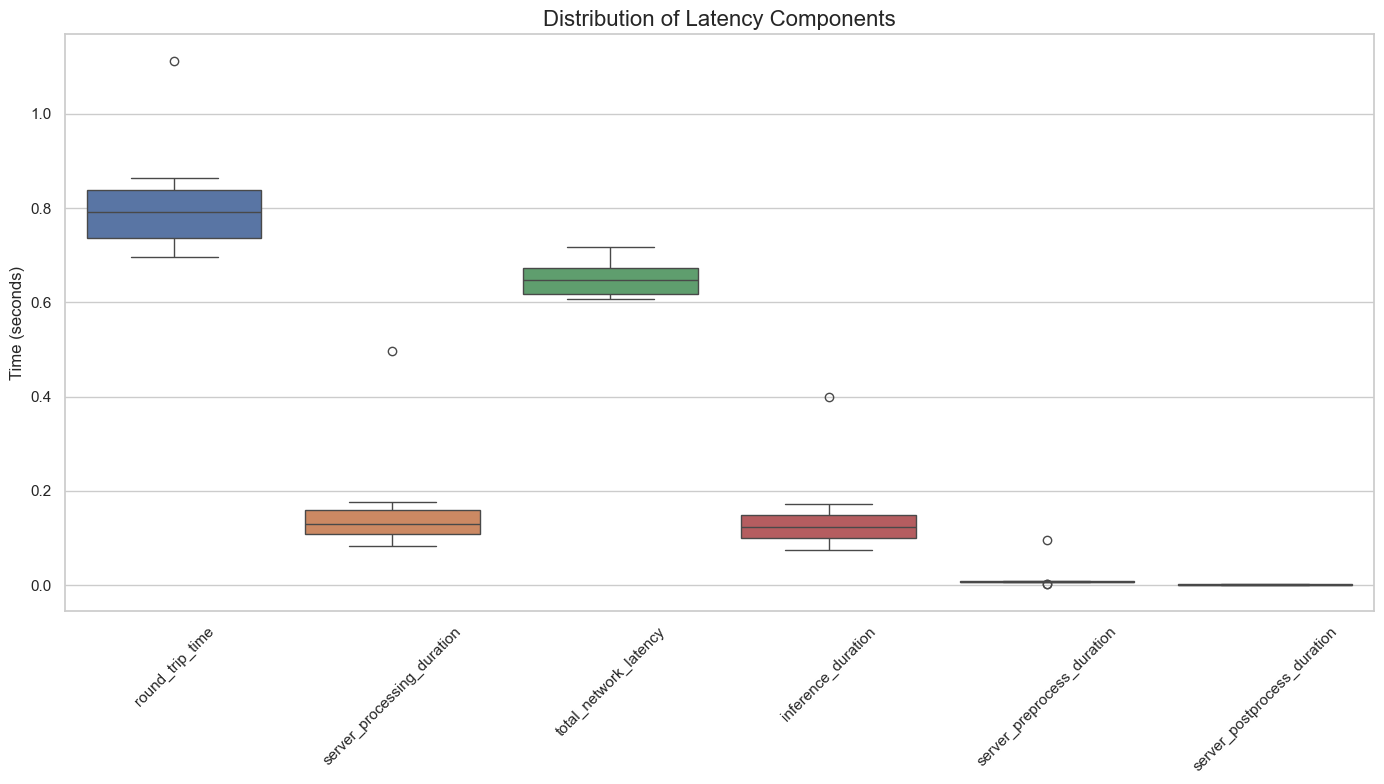

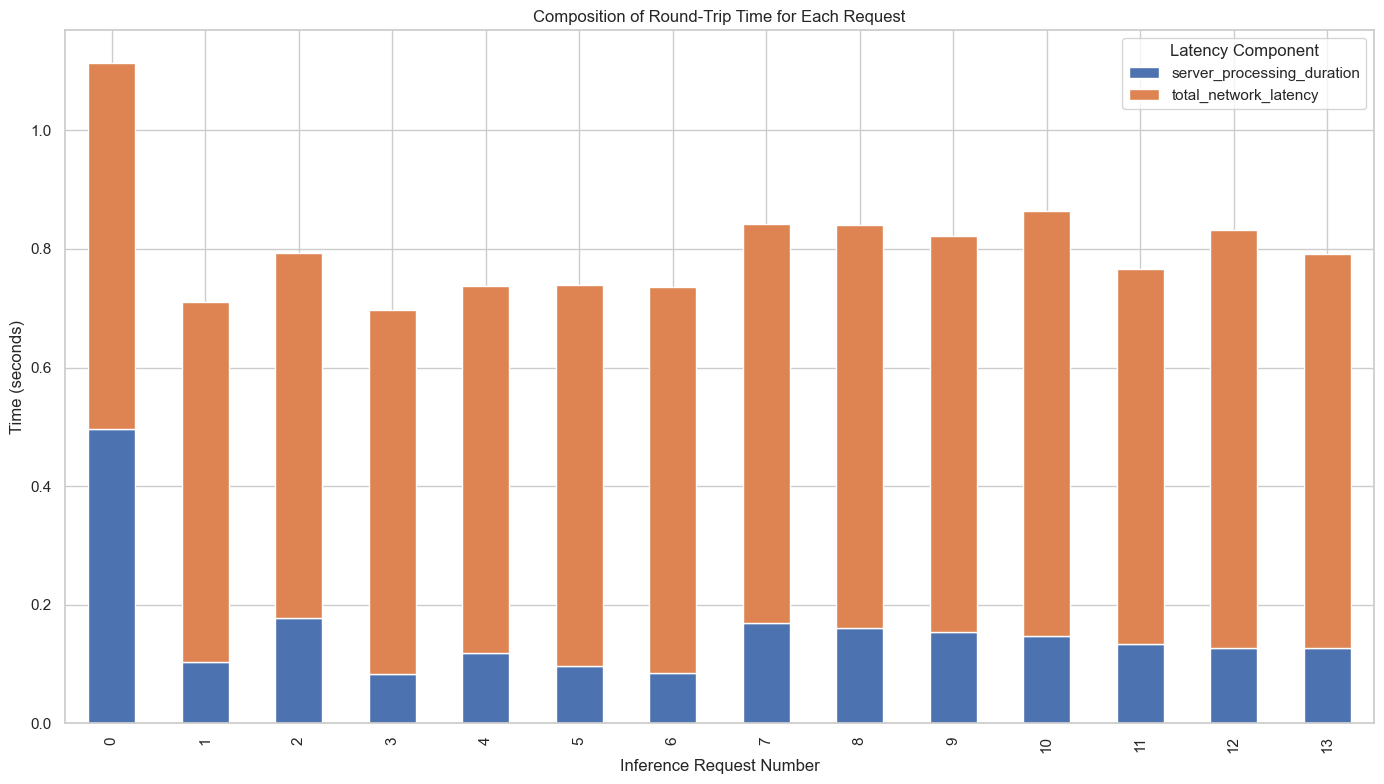

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the duration of each stage by finding the difference between timestamps
data['inference_duration'] = data['inference_end_time'] - data['inference_start_time']
data['server_preprocess_duration'] = data['inference_start_time'] - data['preprocess_start_time']
data['server_postprocess_duration'] = data['response_output_time'] - data['postprocess_start_time']


# Create a new DataFrame containing only the calculated durations for clarity
durations_df = data[[
    'round_trip_time',
    'server_processing_duration',
    'total_network_latency',
    'inference_duration',
    'server_preprocess_duration',
    'server_postprocess_duration',
    
]].copy()

# Display summary statistics (mean, std, min, max, etc.) for these durations
print("Summary Statistics for Durations (in seconds):")
display(durations_df.describe())

# --- Visualization ---

# Set up the plot style
sns.set_theme(style="whitegrid")

# Create a boxplot to see the distribution of each latency component
plt.figure(figsize=(14, 8))
sns.boxplot(data=durations_df)
plt.xticks(rotation=45)
plt.title('Distribution of Latency Components', fontsize=16)
plt.ylabel('Time (seconds)')
plt.tight_layout()
plt.show()

# Create a stacked bar chart to show the composition of the round-trip time
plot_data = durations_df[[
    'server_processing_duration',
    'total_network_latency'
]].copy()
plot_data.reset_index(inplace=True) # Use the request number as the x-axis

plot_data.plot(
    x='index',
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    title='Composition of Round-Trip Time for Each Request'
)
plt.xlabel("Inference Request Number")
plt.ylabel("Time (seconds)")
plt.legend(title='Latency Component')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import re

def analyze_results(results_path, parameter_name, x_axis_label):
    """
    Loads all benchmark CSVs from a path, calculates mean latencies,
    and plots the results.
    """
    all_files = glob.glob(os.path.join(results_path, "*.csv"))
    
    summary_data = []

    for f in all_files:
        # Extract the parameter value from the filename
        match = re.search(r'(\d+)\.csv', os.path.basename(f))
        if not match:
            continue
            
        param_value = int(match.group(1))
        
        # Read the data and calculate mean latencies
        df = pd.read_csv(f)
        mean_round_trip = df['round_trip_time'].mean()
        mean_server_processing = df['server_processing_duration'].mean()
        
        summary_data.append({
            parameter_name: param_value,
            'mean_round_trip_time': mean_round_trip,
            'mean_server_processing_time': mean_server_processing
        })

    if not summary_data:
        print(f"No result files found in '{results_path}'. Please check the path and filenames.")
        return

    # Create a DataFrame and sort by the parameter value
    summary_df = pd.DataFrame(summary_data).sort_values(by=parameter_name)
    
    # --- Plotting ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(summary_df[parameter_name], summary_df['mean_round_trip_time'], marker='o', linestyle='-', label='Mean Round-Trip Time')
    ax.plot(summary_df[parameter_name], summary_df['mean_server_processing_time'], marker='x', linestyle='--', label='Mean Server Processing Time')

    ax.set_title(f'Server Latency vs. {x_axis_label}', fontsize=16)
    ax.set_xlabel(x_axis_label, fontsize=12)
    ax.set_ylabel('Mean Latency (seconds)', fontsize=12)
    ax.legend()
    ax.grid(True)
    
    plt.show()


# --- Run the analysis for your two experiments ---

# IMPORTANT: Make sure your CSV files are named like 'gen_len_8.csv', 'prompt_len_48.csv', etc.
# And they are all inside a 'results/' directory in your project root.

# 1. Analyze Generation Length Results
# Assumes your files for this experiment start with "gen_len_"
analyze_results('results', 'generation_length', 'Generation Length (Frames)')

# 2. Analyze Prompt Length Results
# Assumes your files for this experiment start with "prompt_len_"
analyze_results('results', 'prompt_length', 'Prompt Length (Ticks)')
